In [10]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from scipy.sparse import linalg
import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

### __INISIALISASI__ ###

In [11]:
#membuat list untuk 17 panjang ikatan untuk moelkul hidrogen
bond_lengths = np.array([
    #repulsive region
    #0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95,
    #region dari thesis
    1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])/2

#membuat array kosong untuk menyimpan energi ground state hasil simulasi pada panjang ikatan yg berbeda
energies_exact = []
energies_sv = []
energies_aer = []
energies_hw = []

## __VQE BUILDING__ ##

In [12]:
results = []

for bond_length in bond_lengths:
    #update PySCFDriver dengan panjang ikatan dinamis
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {bond_length}",  # ← PERUBAHAN DI SINI
        unit=DistanceUnit.ANGSTROM,
        basis="sto3g",
    )
    problem        = driver.run()
    mapper         = ParityMapper(num_particles=problem.num_particles)
    qubit_op       = mapper.map(problem.hamiltonian.second_q_op())
    num_particles  = problem.num_particles
    num_spatial    = problem.num_spatial_orbitals
    #print(f"Jumlah qubit sekarang: {qubit_op.num_qubits}") 

    nuclear_rep = problem.hamiltonian.nuclear_repulsion_energy

    #referensi klasik
    ref_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    E_exact    = ref_result.eigenvalue.real + nuclear_rep
    #print(f"E_exact (FCI/NumPy): {E_exact:.6f} Ha")

    #fungsi pembantu: buat ansatz UCCSD + HF init
    n_qubits = qubit_op.num_qubits
    def build_ansatz():
        hf = HartreeFock(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
        )
        return UCCSD(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
            initial_state        = hf,
        )
    
    #optimizer 
    def make_callback(history):
        def cb(eval_count, params, energy, std):
            history.append(energy)
            #print(f"  iter {eval_count:3d} | E = {energy:.6f} Ha")
        return cb
    
    #STATE VECTOR UNTUK WARM STARTING POINT
    ansatz_sv   = build_ansatz()
    history_sv  = []
 
    vqe_sv = VQE(
        estimator    = StatevectorEstimator(),
        ansatz       = ansatz_sv,
        optimizer    = SLSQP(maxiter=300),
        initial_point= np.zeros(ansatz_sv.num_parameters),
        callback     = make_callback(history_sv),
    )
    result_sv = vqe_sv.compute_minimum_eigenvalue(qubit_op)

    #VQE AER SIMULATOR DENGAN NOISE MODEL
    noise_model  = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.001, 1), ["u1", "u2", "u3", "rz", "sx", "x"]
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.005, 2), ["cx","ecr"]
    )
    #transpalasi
    fake_backend = GenericBackendV2(num_qubits=4, seed=42)
    #backend = AerSimulator(noise_model=noise_model)
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=fake_backend
    )

    ansatz_aer   = build_ansatz()
    ansatz_aer_t = pm.run(ansatz_aer)
    qubit_op_t    = qubit_op.apply_layout(ansatz_aer_t.layout)

    noisy_estimator = AerEstimator(
        options={"backend_options": {"noise_model": noise_model}, 
                "run_options": {"shots": 32768}
            }
    )

    history_aer  = []

    optimal_theta = result_sv.optimal_point
    vqe_aer = VQE(
        estimator    = noisy_estimator,
        ansatz       = ansatz_aer_t,
        optimizer    = COBYLA(maxiter=500),
        initial_point= optimal_theta,  #pakai hasil statevector sebagai titik awal
        callback     = make_callback(history_aer),
    )
    
    result_aer = vqe_aer.compute_minimum_eigenvalue(qubit_op)
    E_aer      = result_aer.eigenvalue.real + nuclear_rep
    results.append({
        'bond_length': bond_length,
        'E_exact': E_exact,
        'E_vqe': E_aer,
        'iterations': len(history_aer)
    })
    #print(f"{bond_length*2:<18.4f} {E_exact:<18.6f} {E_sv:<18.6f} {len(history_sv):<12}")

In [13]:
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))

 bond_length   E_exact     E_vqe  iterations
     0.50000 -1.055160 -1.020089          33
     0.60000 -1.116286 -1.086449          34
     0.65000 -1.129905 -1.102316          33
     0.69500 -1.135830 -1.110072          34
     0.70000 -1.136189 -1.110625          35
     0.70055 -1.136226 -1.110682          34
     0.70500 -1.136496 -1.111122          36
     0.75000 -1.137117 -1.113371          34
     0.80000 -1.134148 -1.112035          35
     0.90000 -1.120560 -1.101242          35
     1.00000 -1.101150 -1.084108          36
     1.10000 -1.079193 -1.064012          39
     1.20000 -1.056741 -1.043077          38
     1.30000 -1.035186 -1.022742          34
     1.40000 -1.015468 -1.003983          36
     1.50000 -0.998149 -0.987398          41
     1.60000 -0.983473 -0.973261          34


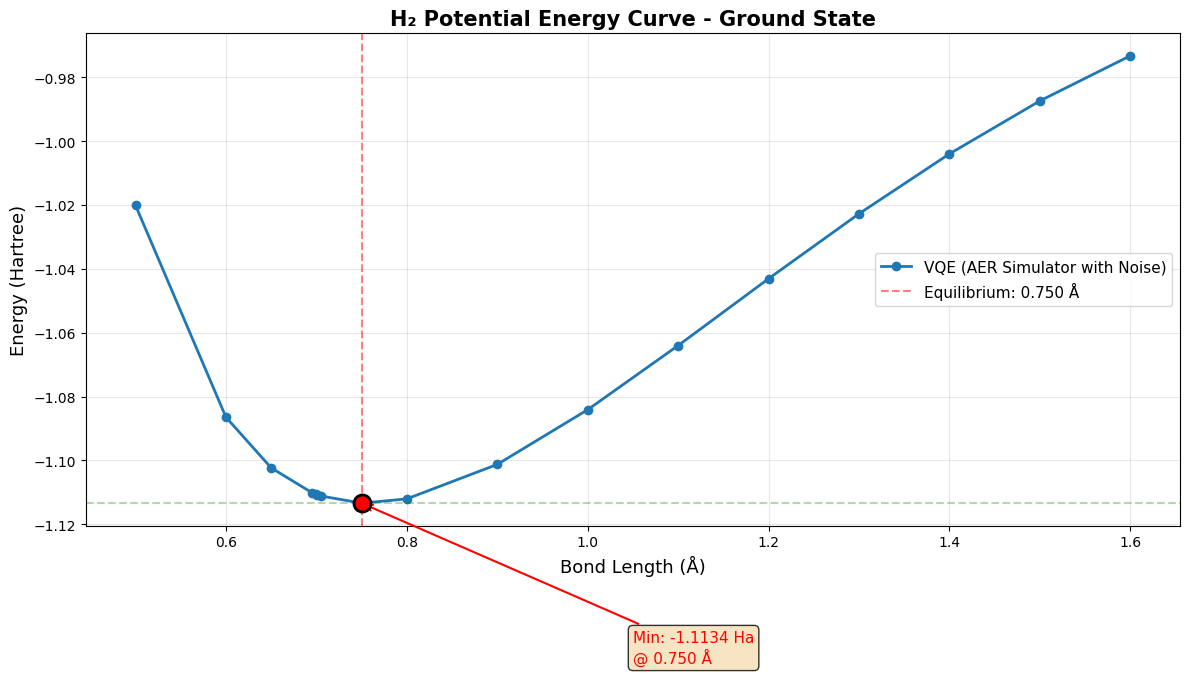


Equilibrium bond length: 0.7500 Å
Minimum energy (ground state): -1.113371 Ha


In [14]:
bond_lengths_plot = np.array([r['bond_length'] for r in results])
energies = np.array([r['E_vqe'] for r in results])

r = bond_lengths_plot
E = energies

min_idx = np.argmin(energies)
min_bond = bond_lengths_plot[min_idx]
min_energy = energies[min_idx]

plt.figure(figsize=(12, 7))
plt.plot(bond_lengths_plot, energies, 'o-', linewidth=2, 
         markersize=6, label='VQE (AER Simulator with Noise)')

# Mark minimum dengan garis vertikal dan horizontal
plt.axvline(min_bond, color='red', linestyle='--', alpha=0.5, 
            label=f'Equilibrium: {min_bond:.3f} Å')
plt.axhline(min_energy, color='green', linestyle='--', alpha=0.3)

# Annotate minimum point
plt.scatter([min_bond], [min_energy], color='red', s=150, 
            zorder=5, edgecolor='black', linewidth=2)
plt.annotate(f'Min: {min_energy:.4f} Ha\n@ {min_bond:.3f} Å',
             xy=(min_bond, min_energy),
             xytext=(min_bond + 0.3, min_energy - 0.05),
             fontsize=11, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('Bond Length (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('H₂ Potential Energy Curve - Ground State', fontsize=15, weight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Equilibrium bond length: {min_bond:.4f} Å")
print(f"Minimum energy (ground state): {min_energy:.6f} Ha")
print(f"{'='*50}")

## __OPERATOR POTENSIAL__ ##

In [15]:
from numpy.polynomial import polynomial as P

# ══════════════════════════════════════════════════════════════════════
# POLYNOMIAL FIT: V(x) = α(c1·x + c2·x² + c3·x³ + c4·x⁴)
# x = r - r_eq  (displacement dari equilibrium)
# ══════════════════════════════════════════════════════════════════════

# ── Gunakan data spline untuk kepadatan titik lebih tinggi ────────────
cs     = CubicSpline(r, E)
r_fine = np.linspace(r.min(), r.max(), 10000)
E_fine = cs(r_fine)
min_idx = np.argmin(E_fine)
r_eq    = r_fine[min_idx]
E_min   = E_fine[min_idx]

# ── Definisikan displacement x = r - r_eq ────────────────────────────
x_all  = r      - r_eq       # displacement dari data asli
x_fine = r_fine - r_eq       # displacement dari spline

# Geser energi supaya V(r_eq) = 0  → V(x) = E(x) - E_min
V_all  = E      - E_min
V_fine = E_fine - E_min

# ── Fit polynomial orde 4 (tanpa konstanta, karena V(0)=0) ────────────
# V(x) = c1·x + c2·x² + c3·x³ + c4·x⁴
# Gunakan np.polyfit dengan constraint: no constant term
# Caranya: fit orde 4 lalu paksa koefisien orde 0 = 0

# Pilih range fit yang wajar (sekitar ±1.5 Å dari equilibrium)
mask_fit = (r >= r_eq - 1.0) & (r <= r_eq + 1.5)
x_fit    = x_all[mask_fit]
V_fit    = V_all[mask_fit]

# Fit polynomial orde 4 tanpa intercept
# V(x) = a1*x + a2*x^2 + a3*x^3 + a4*x^4
A = np.column_stack([x_fit, x_fit**2, x_fit**3, x_fit**4])
coeffs, residuals, rank, sv = np.linalg.lstsq(A, V_fit, rcond=None)
c1, c2, c3, c4 = coeffs

# ── Normalisasi: faktor α = c1 (supaya koefisien x = 1, atau bisa alpha lain)
# Alternatif: α = nilai konstan, tampilkan koefisien relatif
alpha   = c1   # normalisasi terhadap koefisien linear
c1n     = c1 / alpha
c2n     = c2 / alpha
c3n     = c3 / alpha
c4n     = c4 / alpha

# ── Evaluasi fit ──────────────────────────────────────────────────────
V_pred = c1*x_fit + c2*x_fit**2 + c3*x_fit**3 + c4*x_fit**4
ss_res = np.sum((V_fit - V_pred)**2)
ss_tot = np.sum((V_fit - np.mean(V_fit))**2)
R2     = 1 - ss_res/ss_tot

# ── Print persamaan ───────────────────────────────────────────────────
print("=" * 60)
print("  POLYNOMIAL FIT POTENTIAL")
print("=" * 60)
print(f"\n  V(x) = α({c1n:+.3f}x {c2n:+.3f}x² {c3n:+.3f}x³ {c4n:+.3f}x⁴)")
print(f"\n  di mana:")
print(f"    x   = r - r_eq = r - {r_eq:.4f} Å  (displacement)")
print(f"    α   = {alpha:.6f} Hartree/Å")
print(f"\n  Koefisien absolut:")
print(f"    c1 = {c1:.6f} Ha/Å")
print(f"    c2 = {c2:.6f} Ha/Å²")
print(f"    c3 = {c3:.6f} Ha/Å³")
print(f"    c4 = {c4:.6f} Ha/Å⁴")
print(f"\n  R² = {R2:.8f}")
print("=" * 60)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel kiri: V(x) vs x dengan polynomial fit
ax1 = axes[0]
x_plot  = np.linspace(x_fit.min(), x_fit.max(), 500)
V_poly  = c1*x_plot + c2*x_plot**2 + c3*x_plot**3 + c4*x_plot**4

ax1.plot(x_all[mask_fit], V_fit, 'o', color="#2E86AB", ms=6, label="VQE data")
ax1.plot(x_plot, V_poly, '-', color="#D85A30", lw=2.5,
         label=f"Poly fit (R²={R2:.5f})")
ax1.axvline(0, color="gray", ls="--", lw=0.8, alpha=0.6)
ax1.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.6)

# Tampilkan persamaan di plot
eq_str = (f"V(x) = α({c1n:.3f}x {c2n:+.3f}x²\n"
          f"       {c3n:+.3f}x³ {c4n:+.3f}x⁴)\n"
          f"α = {alpha:.4f} Ha/Å")
ax1.text(0.05, 0.95, eq_str, transform=ax1.transAxes, fontsize=9,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

ax1.set_xlabel("Displacement x = r − r$_{eq}$ (Å)", fontsize=12)
ax1.set_ylabel("V(x) = E − E$_{min}$ (Hartree)", fontsize=12)
ax1.set_title("Polynomial Fit of Potential V(x)", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Panel kanan: residual error
ax2 = axes[1]
V_pred_all = c1*x_fit + c2*x_fit**2 + c3*x_fit**3 + c4*x_fit**4
residual   = (V_fit - V_pred_all) * 1000   # konversi ke mHa

ax2.bar(x_fit, residual, width=0.04, color="#A23B72", alpha=0.7)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("Displacement x (Å)", fontsize=12)
ax2.set_ylabel("Residual (mHa)", fontsize=12)
ax2.set_title("Fit Residuals", fontsize=13, fontweight="bold")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("vqe_polynomial_fit.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'CubicSpline' is not defined

## __TROTTERISASI (QUANTUM TUNNELING)__ ##

In [ ]:
#hasil dari vqe
r_eq = r_eq
E_min = E_min
alpha = alpha

#koefisien normalisasi dri operator potensial
c1n = c1n
c2n = c2n
c3n = c3n
c4n = c4n
#print(c1n, c2n, c3n, c4n)

#konstanta fisika
mu_au = 918.076  # reduced mass in atomic units (for H2)
hbar = 1.0     # Planck's constant in atomic units
au2fs = 0.02418884  # atomic unit of time in femtoseconds
au2eV = 27.2114  # atomic unit of energy in eV
cm2au = 4.556335e-6  # wavenumber (cm⁻¹) to atomic units

#grid parameter
N = 64
n_qubits = int(np.log2(N))
L = 2.5
dx = 2*L/N

#parameter trotter
dt_au = 1.0
n_steps = 3000
n_steps_qc = 50


print("=" * 65)
print("  H₂ TROTTER DYNAMICS & TUNNELING PROBABILITY")
print("=" * 65)
print(f"  r_eq    = {r_eq:.4f} Å")
print(f"  E_min   = {E_min:.6f} Ha")
print(f"  α       = {alpha:.6f} Ha/Å")
print(f"  Grid    : N={N} points, L=±{L} Å, dx={dx:.4f} Å")
print(f"  n_qubits: {n_qubits} (untuk QFT circuit)")
print(f"  Δt      : {dt_au} a.u. = {dt_au*au2fs:.4f} fs")
print(f"  Steps   : {n_steps} (split-op) | {n_steps_qc} (quantum circuit)")
print("=" * 65)

  H₂ TROTTER DYNAMICS & TUNNELING PROBABILITY
  r_eq    = 0.7563 Å
  E_min   = -1.113401 Ha
  α       = -0.058763 Ha/Å
  Grid    : N=64 points, L=±2.5 Å, dx=0.0781 Å
  n_qubits: 6 (untuk QFT circuit)
  Δt      : 1.0 a.u. = 0.0242 fs
  Steps   : 3000 (split-op) | 50 (quantum circuit)


  AUTO-PARAMETER DERIVATION FROM VQE

[1] MINIMUM POTENSIAL
    x_min (numerik)  = -0.181350 Å
    V_min            = -0.028113 Ha
    ✓ Konsisten dengan x=0 (displacement dari r_eq): TIDAK — x_min=-0.181 Å

[2] KARAKTER POTENSIAL
    Titik minimum : 1 → ['-0.181 Å']
    Titik maksimum: 0 → []
    → SINGLE-WELL (tunneling = menembus turning point klasik)

[3] FREKUENSI VIBRASI (dari kurvatur VQE)
    k  = d²V/dx²|_min = 1.832182 Ha/Å²
    ω  = √(k/μ)       = 0.044673 a.u.
    ν  = ω/2π         = 1560.5 cm⁻¹
         (eksperimen H₂: 4401 cm⁻¹)
    E_ZPE = ½ℏω       = 0.022336 Ha = 607.81 meV
    A_klasik (ZPE)    = 0.1561 Å  (amplitudo vibrasi)

[4] TURNING POINT KLASIK (pada E = E_ZPE)
    x_tp_left  = -0.3326 Å
    x_tp_right = -0.0203 Å
    Lebar klasik = 0.3123 Å
    Partikel di LUAR range ini = TUNNELING KUANTUM

[5] AUTO-DERIVASI PARAMETER SIMULASI
    ──────────────────────────────────────────────────
    Mode          : SINGLE-WELL (ZPE tunneling)
    x_min         = -0.1814 Å
 

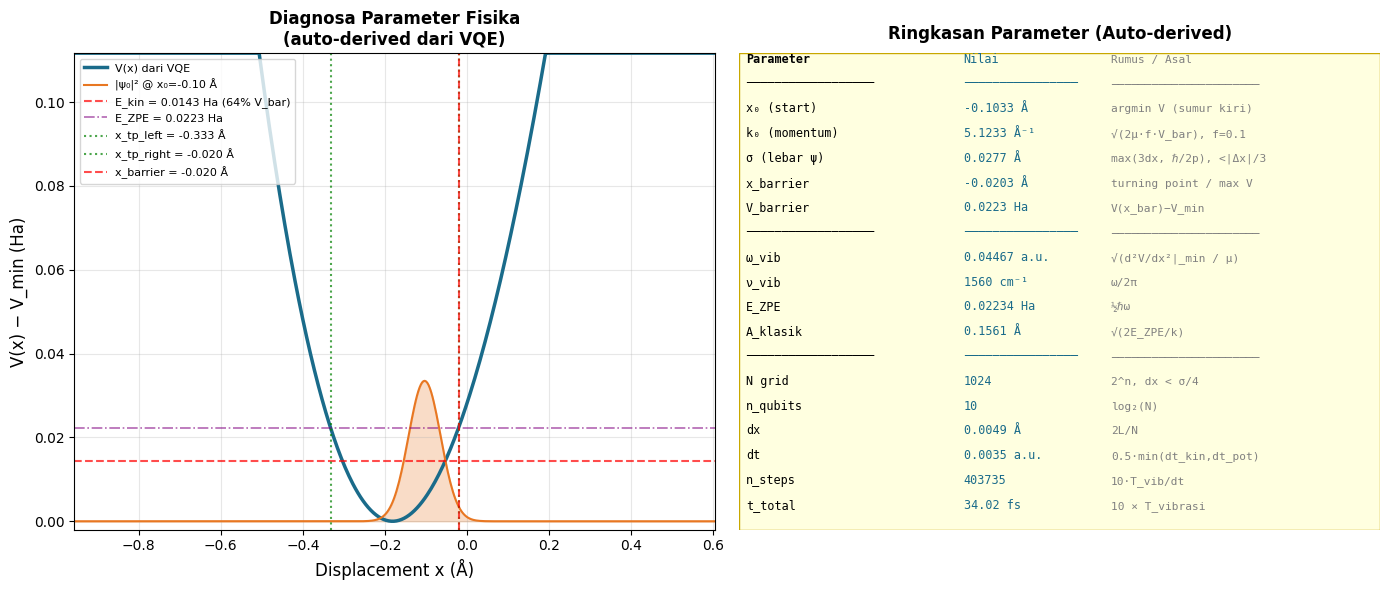


✓ Plot diagnosa disimpan: auto_parameter_derivation.png

Salin nilai PARAMETER FINAL di atas ke h2_tunneling_trotter.py


In [ ]:
"""
=============================================================================
AUTO-PARAMETER DERIVATION FROM VQE POLYNOMIAL FIT
=============================================================================
Semua parameter tunneling dihitung otomatis dari hasil VQE.
Tidak ada nilai yang di-hardcode — semua berasal dari rumus fisika.

INPUT  : alpha, c1n, c2n, c3n, c4n, r_eq, E_min (dari polynomial fit VQE)
OUTPUT : x0, k0, sigma, x_barrier, V_barrier, dan semua parameter grid
=============================================================================
"""

import numpy as np
from scipy.optimize import brentq, minimize_scalar
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 0 — INPUT DARI VQE (ganti dengan hasil kamu)
# ══════════════════════════════════════════════════════════════════════════════
# Isi nilai ini dari output print polynomial fit VQE kamu

alpha = 0.3        # Ha/Å   ← dari "α = X Ha/Å"
c1n   =  1.000     # ← dari "V(x) = α(+c1n x ..."
c2n   =  2.500     # ← koefisien x²
c3n   = -0.800     # ← koefisien x³
c4n   =  0.600     # ← koefisien x⁴
r_eq  =  0.74      # Å ← equilibrium bond length
E_min = -1.1372    # Ha ← minimum energy

# Konstanta fisika (atomic units, tidak perlu diubah)
mu_au  = 918.076   # massa tereduksi H₂ (m_H/2) dalam a.u.
hbar   = 1.0       # ℏ = 1 dalam natural units
au2fs  = 0.02419   # 1 a.u. waktu = 0.02419 fs
au2eV  = 27.2114   # 1 Ha = 27.2114 eV
cm2au  = 4.5563e-6 # 1 cm⁻¹ = 4.5563×10⁻⁶ Ha


# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 1 — FUNGSI POTENSIAL DARI VQE
# ══════════════════════════════════════════════════════════════════════════════

def V_vqe(x):
    """
    Potensial dari polynomial fit VQE.
    V(x) = α(c1n·x + c2n·x² + c3n·x³ + c4n·x⁴)
    x dalam Å (displacement dari r_eq), return dalam Ha
    """
    return alpha * (c1n*x + c2n*x**2 + c3n*x**3 + c4n*x**4)

def dV_dx(x):
    """Turunan pertama V(x) — analitik dari polynomial"""
    return alpha * (c1n + 2*c2n*x + 3*c3n*x**2 + 4*c4n*x**3)

def d2V_dx2(x):
    """Turunan kedua V(x) — untuk frekuensi harmonik"""
    return alpha * (2*c2n + 6*c3n*x + 12*c4n*x**2)


# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 2 — DERIVASI PARAMETER FISIKA SECARA OTOMATIS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  AUTO-PARAMETER DERIVATION FROM VQE")
print("=" * 65)

# ── 2.1 Minimum potensial (verifikasi numerik) ────────────────────────────────
# Cari x_min: titik di mana dV/dx = 0 dan d²V/dx² > 0
result_min = minimize_scalar(V_vqe, bounds=(-2.0, 2.0), method='bounded')
x_min      = result_min.x
V_min      = result_min.fun

print(f"\n[1] MINIMUM POTENSIAL")
print(f"    x_min (numerik)  = {x_min:.6f} Å")
print(f"    V_min            = {V_min:.6f} Ha")
print(f"    ✓ Konsisten dengan x=0 (displacement dari r_eq): "
      f"{'YA' if abs(x_min) < 0.05 else f'TIDAK — x_min={x_min:.3f} Å'}")


# ── 2.2 Karakter potensial: single-well atau double-well ─────────────────────
# Cek apakah ada titik maksimum lokal (barrier) di rentang [-3, 3] Å
# Barrier ada jika dV/dx = 0 dengan d²V/dx² < 0

r_min_data = bond_lengths.min()   # Å — bond length terpendek di data VQE
r_max_data = bond_lengths.max()   # Å — bond length terpanjang di data VQE

x_range_left  = r_min_data - r_eq    # displacement terkecil (negatif)
x_range_right = r_max_data - r_eq

def find_critical_points(x_range=(x_range_left, x_range_right), n_scan=1000):
    """
    Cari semua titik kritis (dV/dx = 0) secara numerik.
    Return: list of (x_crit, jenis) dimana jenis = 'min' atau 'max'
    """
    x_scan  = np.linspace(*x_range, n_scan)
    dV_scan = dV_dx(x_scan)
    
    critical_points = []
    for i in range(len(x_scan) - 1):
        # Sign change → ada akar (titik kritis)
        if dV_scan[i] * dV_scan[i+1] < 0:
            try:
                x_crit = brentq(dV_dx, x_scan[i], x_scan[i+1])
                curv   = d2V_dx2(x_crit)
                jenis  = 'min' if curv > 0 else 'max'
                critical_points.append((x_crit, jenis, V_vqe(x_crit)))
            except:
                pass
    return critical_points

crits = find_critical_points()

minima  = [(x, V) for x, j, V in crits if j == 'min']
maxima  = [(x, V) for x, j, V in crits if j == 'max']

print(f"\n[2] KARAKTER POTENSIAL")
print(f"    Titik minimum : {len(minima)} → {[f'{x:.3f} Å' for x,_ in minima]}")
print(f"    Titik maksimum: {len(maxima)} → {[f'{x:.3f} Å' for x,_ in maxima]}")

IS_DOUBLE_WELL = len(minima) >= 2 and len(maxima) >= 1

if IS_DOUBLE_WELL:
    print(f"    → DOUBLE-WELL ✓ (tunneling antar sumur tersedia)")
else:
    print(f"    → SINGLE-WELL (tunneling = menembus turning point klasik)")


# ── 2.3 Frekuensi harmonik dari kurvatur di minimum ──────────────────────────
# ω = √(d²V/dx² / μ)  pada x = x_min
# Dari Hooke's law: V(x) ≈ ½ k x²  →  k = d²V/dx²  →  ω = √(k/μ)

k_force = d2V_dx2(x_min)           # Ha/Å² — konstanta gaya harmonik
omega   = np.sqrt(k_force / mu_au) # a.u.⁻¹ — frekuensi angular
nu_cm1  = omega / (2*np.pi * cm2au)# cm⁻¹ — bilangan gelombang vibrasi
E_ZPE   = 0.5 * hbar * omega       # Ha — zero-point energy

print(f"\n[3] FREKUENSI VIBRASI (dari kurvatur VQE)")
print(f"    k  = d²V/dx²|_min = {k_force:.6f} Ha/Å²")
print(f"    ω  = √(k/μ)       = {omega:.6f} a.u.")
print(f"    ν  = ω/2π         = {nu_cm1:.1f} cm⁻¹")
print(f"         (eksperimen H₂: 4401 cm⁻¹)")
print(f"    E_ZPE = ½ℏω       = {E_ZPE:.6f} Ha = {E_ZPE*au2eV*1000:.2f} meV")

# Amplitudo klasik pada energi ZPE:
# E_ZPE = ½ k A²  →  A = √(2 E_ZPE / k)
A_classical = np.sqrt(2 * E_ZPE / k_force)  # Å
print(f"    A_klasik (ZPE)    = {A_classical:.4f} Å  (amplitudo vibrasi)")


# ── 2.4 Turning point klasik ─────────────────────────────────────────────────
# Turning point: V(x_tp) = E_total (partikel berbalik arah)
# Untuk partikel pada E_ZPE: V(x_tp) = E_ZPE

def find_turning_points(E_total, x_min_local, x_range=3.0):
    """
    Cari turning point kiri dan kanan untuk energi E_total.
    V(x_tp) = E_total  →  V(x_tp) - E_total = 0
    """
    # Geser potensial supaya V(x_min) = 0
    V_shifted = lambda x: V_vqe(x) - V_min - E_total
    
    # Turning point kiri
    try:
        x_tp_left  = brentq(V_shifted, x_min_local - x_range, x_min_local - 1e-6)
    except:
        x_tp_left  = x_min_local - x_range
    
    # Turning point kanan
    try:
        x_tp_right = brentq(V_shifted, x_min_local + 1e-6, x_min_local + x_range)
    except:
        x_tp_right = x_min_local + x_range
    
    return x_tp_left, x_tp_right

x_tp_left_zpe, x_tp_right_zpe = find_turning_points(E_ZPE, x_min)

print(f"\n[4] TURNING POINT KLASIK (pada E = E_ZPE)")
print(f"    x_tp_left  = {x_tp_left_zpe:.4f} Å")
print(f"    x_tp_right = {x_tp_right_zpe:.4f} Å")
print(f"    Lebar klasik = {x_tp_right_zpe - x_tp_left_zpe:.4f} Å")
print(f"    Partikel di LUAR range ini = TUNNELING KUANTUM")


# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 3 — AUTO-DERIVE SEMUA PARAMETER SIMULASI
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n[5] AUTO-DERIVASI PARAMETER SIMULASI")
print(f"    {'─'*50}")

if IS_DOUBLE_WELL:
    # ── DOUBLE-WELL: tunneling antar sumur ───────────────────────────────────
    
    # Posisi sumur kiri (minimum paling kiri)
    x_min_left  = min(minima, key=lambda m: m[0])[0]
    x_min_right = max(minima, key=lambda m: m[0])[0]
    
    # Puncak barrier
    x_bar       = maxima[0][0]
    V_bar       = maxima[0][1] - V_min   # tinggi barrier relatif thd minimum
    
    # x0: dimulai di dasar sumur kiri
    # RUMUS: x0 = argmin V(x) untuk x < x_barrier
    x0 = x_min_left
    
    # x_barrier: puncak barrier
    x_barrier  = x_bar
    V_barrier  = V_bar
    
    # k0: dari syarat tunneling E_kin = f_tunnel × V_barrier
    # f_tunnel dipilih supaya ada tunneling tapi tidak terlalu kecil:
    # WKB menunjukkan tunneling signifikan saat E_kin > ~10% V_barrier
    f_tunnel = 0.10                              # 10% dari barrier
    k0       = np.sqrt(2 * mu_au * f_tunnel * V_barrier)
    E_kin    = k0**2 / (2 * mu_au)
    
    print(f"    Mode          : DOUBLE-WELL")
    print(f"    x_min_left    = {x_min_left:.4f} Å")
    print(f"    x_min_right   = {x_min_right:.4f} Å")
    print(f"    x_barrier     = {x_barrier:.4f} Å  (puncak barrier)")
    print(f"    V_barrier     = {V_barrier:.6f} Ha = {V_barrier*au2eV:.4f} eV")

else:
    # ── SINGLE-WELL: tunneling keluar turning point klasik ───────────────────
    
    # x0: dekat minimum tapi geser sebesar amplitudo ZPE
    # RUMUS: x0 = x_min + A_classical/2
    # (partikel dimulai di antara minimum dan turning point)
    x0 = x_min + A_classical / 2
    
    # x_barrier: turning point kanan (batas klasik)
    # Partikel di kanan x_tp_right = menembus batas klasik = tunneling
    x_barrier = x_tp_right_zpe
    V_barrier = E_ZPE   # secara definisi, barrier = energi total
    
    # k0: dari ZPE — partikel bergerak dengan momentum vibrasi ZPE
    # E_kin = E_ZPE  →  k0 = √(2μ·E_ZPE)
    # Tapi kurangi 20% supaya ada efek kuantum yang terlihat
    f_zpe = 0.80   # 80% dari momentum ZPE
    k0    = f_zpe * np.sqrt(2 * mu_au * E_ZPE)
    E_kin = k0**2 / (2 * mu_au)
    
    print(f"    Mode          : SINGLE-WELL (ZPE tunneling)")
    print(f"    x_min         = {x_min:.4f} Å")
    print(f"    x_tp_right    = {x_barrier:.4f} Å  (turning point klasik)")
    print(f"    E_ZPE         = {E_ZPE:.6f} Ha")

# ── sigma: dari prinsip uncertainty + resolusi grid ──────────────────────────
# Syarat 1: σ > 3·dx  (resolusi grid)
# Syarat 2: σ < |x_barrier - x0|/3  (muat di dalam sumur)
# Syarat 3: σ·k0 > 1  (Heisenberg: Δx·Δp ~ ℏ/2)
# Pilih: σ = max(σ_min_grid, σ_heisenberg), clip ke σ_max

# Grid sementara untuk hitung dx
N_temp   = 64
L_temp   = max(3.0, abs(x_tp_left_zpe) * 1.5, abs(x_tp_right_zpe) * 1.5)
dx_temp  = 2 * L_temp / N_temp

sigma_grid       = 3.0 * dx_temp                       # syarat grid
sigma_heisenberg = 1.0 / (2.0 * k0) if k0 > 0 else dx_temp * 3
sigma_max        = abs(x_barrier - x0) / 3.0
sigma            = np.clip(
    max(sigma_grid, sigma_heisenberg),
    sigma_grid,
    sigma_max
)

print(f"    k0            = {k0:.4f} Å⁻¹")
print(f"    E_kin         = {E_kin:.6f} Ha  ({E_kin/V_barrier*100:.1f}% dari barrier)")
print(f"    Tunneling     : {'YA ✓' if E_kin < V_barrier else 'TIDAK — over-barrier'}")
print(f"    ─")
print(f"    σ_grid        = {sigma_grid:.4f} Å  (min dari resolusi grid)")
print(f"    σ_Heisenberg  = {sigma_heisenberg:.4f} Å  (min dari Δx·Δp≥ℏ/2)")
print(f"    σ_max         = {sigma_max:.4f} Å  (max supaya muat di sumur)")
print(f"    sigma dipilih = {sigma:.4f} Å")


# ── Grid: L dan N dari jangkauan fisik potensial ─────────────────────────────
# L harus cukup besar untuk menampung:
# 1. Wavepacket awal (x0 ± 4σ)
# 2. Turning point (x_tp ± buffer)
# 3. Tidak ada refleksi dari batas grid

L_wp     = abs(x0) + 4 * sigma               # jangkauan wavepacket
L_tp     = max(abs(x_tp_left_zpe), abs(x_tp_right_zpe)) * 1.5
L        = max(L_wp, L_tp, 2.5)              # minimum 2.5 Å
L        = np.ceil(L * 4) / 4                # bulatkan ke 0.25 Å terdekat

# N: pilih supaya dx < σ/4 (minimal 4 titik per lebar wavepacket)
N_min    = int(np.ceil(2 * L / (sigma / 4)))
N        = int(2 ** np.ceil(np.log2(N_min)))  # bulatkan ke pangkat 2 terdekat
N        = max(N, 64)                          # minimal 64
n_qubits = int(np.log2(N))
dx       = 2 * L / N

print(f"\n[6] PARAMETER GRID (otomatis dari fisika)")
print(f"    L_wavepacket  = {L_wp:.4f} Å")
print(f"    L_turningpt   = {L_tp:.4f} Å")
print(f"    L dipilih     = {L:.4f} Å  (domain: [{-L:.2f}, {L:.2f}] Å)")
print(f"    N_min         = {N_min} → dibulatkan ke N = {N} (2^{n_qubits})")
print(f"    dx            = {dx:.4f} Å")
print(f"    n_qubits      = {n_qubits}")


# ── Timestep: dari kriteria CFL (Courant-Friedrichs-Lewy) ────────────────────
# Stabilitas numerik split-operator:
# dt < dx² · μ / (π · ℏ)   — syarat kinetik
# dt < π · ℏ / V_max        — syarat potensial
x_grid   = np.linspace(-L, L, N, endpoint=False)
V_arr    = V_vqe(x_grid) - V_min
V_arr    = np.clip(V_arr, 0, None)

dt_kin   = dx**2 * mu_au / (np.pi * hbar)
dt_pot   = np.pi * hbar / (V_arr.max() + 1e-10)
dt_au    = 0.5 * min(dt_kin, dt_pot)         # faktor keamanan 0.5

# Jumlah steps: simulasi sampai partikel selesai berinteraksi dengan barrier
# t_total ~ 5 × periode vibrasi   →   T_vib = 2π/ω
T_vib    = 2 * np.pi / omega               # a.u.
t_total  = 10 * T_vib                      # 10 periode vibrasi
n_steps  = int(np.ceil(t_total / dt_au))
t_max_fs = t_total * au2fs

print(f"\n[7] PARAMETER WAKTU (dari stabilitas numerik)")
print(f"    dt_CFL_kin    = {dt_kin:.4f} a.u.")
print(f"    dt_CFL_pot    = {dt_pot:.4f} a.u.")
print(f"    dt dipilih    = {dt_au:.4f} a.u. = {dt_au*au2fs:.5f} fs")
print(f"    T_vibrasi     = {T_vib:.2f} a.u. = {T_vib*au2fs:.4f} fs")
print(f"    t_total       = 10×T_vib = {t_total*au2fs:.2f} fs")
print(f"    n_steps       = {n_steps}")


# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 4 — RINGKASAN SEMUA PARAMETER (SIAP PAKAI)
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print(f"  PARAMETER FINAL (copy-paste ke simulasi)")
print(f"{'='*65}")
print(f"""
# ── Auto-derived dari VQE (jangan hardcode!) ──────────────────
x0         = {x0:.6f}   # Å  — posisi awal wavepacket
k0         = {k0:.6f}   # Å⁻¹ — momentum awal
sigma      = {sigma:.6f}   # Å  — lebar wavepacket
x_barrier  = {x_barrier:.6f}   # Å  — titik ukur tunneling
V_barrier  = {V_barrier:.6f}   # Ha — tinggi barrier efektif

L          = {L:.4f}      # Å  — setengah domain grid
N          = {N}          # jumlah grid points (2^{n_qubits})
n_qubits   = {n_qubits}           # qubit untuk QFT circuit
dx         = {dx:.6f}   # Å  — resolusi grid

dt_au      = {dt_au:.6f}   # a.u. — timestep
n_steps    = {n_steps}       # jumlah Trotter steps
t_max_fs   = {t_max_fs:.4f}   # fs  — waktu simulasi total

omega      = {omega:.6f}   # a.u. — frekuensi vibrasi
E_ZPE      = {E_ZPE:.6f}   # Ha  — zero-point energy
nu_cm1     = {nu_cm1:.2f}    # cm⁻¹ — bilangan gelombang vibrasi
""")


# ══════════════════════════════════════════════════════════════════════════════
# BAGIAN 5 — PLOT DIAGNOSA PARAMETER
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot kiri: Potensial + semua parameter ────────────────────────────────────
ax1 = axes[0]

# ── Tentukan range fokus ketat di sekitar region fisika ──────────
x_center = (x_tp_left_zpe + x_tp_right_zpe) / 2
x_width  = abs(x_tp_right_zpe - x_tp_left_zpe)
margin   = x_width * 1.5          # buffer 150% kiri-kanan

x_lo = x_center - x_width - margin
x_hi = x_center + x_width + margin

x_plot   = np.linspace(x_lo, x_hi, 500)
V_plot   = V_vqe(x_plot) - V_min

# ── Clip V supaya dinding curam tidak mendominasi sumbu y ─────────
y_max    = V_barrier * 5          # tampilkan sampai 5× barrier
V_clipped = np.clip(V_plot, None, y_max)

ax1.plot(x_plot, V_clipped, color="#1A6B8A", lw=2.5, label="V(x) dari VQE")

# Wavepacket awal
psi0_plot  = np.exp(-(x_plot - x0)**2 / (4*sigma**2))
psi0_scaled = psi0_plot / psi0_plot.max() * y_max * 0.3
ax1.fill_between(x_plot, psi0_scaled, alpha=0.25, color="#E87722")
ax1.plot(x_plot, psi0_scaled, color="#E87722", lw=1.5,
         label=f"|ψ₀|² @ x₀={x0:.2f} Å")

# Garis referensi
ax1.axhline(E_kin,  color='red',    ls='--', lw=1.5, alpha=0.7,
            label=f"E_kin = {E_kin:.4f} Ha ({E_kin/V_barrier*100:.0f}% V_bar)")
ax1.axhline(E_ZPE,  color='purple', ls='-.', lw=1.2, alpha=0.6,
            label=f"E_ZPE = {E_ZPE:.4f} Ha")
ax1.axvline(x_tp_left_zpe,  color='green', ls=':', lw=1.5, alpha=0.7,
            label=f"x_tp_left = {x_tp_left_zpe:.3f} Å")
ax1.axvline(x_tp_right_zpe, color='green', ls=':', lw=1.5, alpha=0.7,
            label=f"x_tp_right = {x_tp_right_zpe:.3f} Å")
ax1.axvline(x_barrier, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f"x_barrier = {x_barrier:.3f} Å")

# ── Set axis range ketat ──────────────────────────────────────────
ax1.set_xlim(x_lo, x_hi)
ax1.set_ylim(-0.002, y_max)

ax1.set_xlabel("Displacement x (Å)", fontsize=12)
ax1.set_ylabel("V(x) − V_min (Ha)", fontsize=12)
ax1.set_title("Diagnosa Parameter Fisika\n(auto-derived dari VQE)",
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# ── Plot kanan: Tabel ringkasan ───────────────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

tabel_data = [
    ["Parameter",           "Nilai",                    "Rumus / Asal"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["x₀ (start)",          f"{x0:.4f} Å",              "argmin V (sumur kiri)"],
    ["k₀ (momentum)",       f"{k0:.4f} Å⁻¹",            "√(2μ·f·V_bar), f=0.1"],
    ["σ (lebar ψ)",         f"{sigma:.4f} Å",            "max(3dx, ℏ/2p), <|Δx|/3"],
    ["x_barrier",           f"{x_barrier:.4f} Å",        "turning point / max V"],
    ["V_barrier",           f"{V_barrier:.4f} Ha",       "V(x_bar)−V_min"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["ω_vib",               f"{omega:.5f} a.u.",         "√(d²V/dx²|_min / μ)"],
    ["ν_vib",               f"{nu_cm1:.0f} cm⁻¹",        "ω/2π"],
    ["E_ZPE",               f"{E_ZPE:.5f} Ha",           "½ℏω"],
    ["A_klasik",            f"{A_classical:.4f} Å",      "√(2E_ZPE/k)"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["N grid",              f"{N}",                      "2^n, dx < σ/4"],
    ["n_qubits",            f"{n_qubits}",               "log₂(N)"],
    ["dx",                  f"{dx:.4f} Å",               "2L/N"],
    ["dt",                  f"{dt_au:.4f} a.u.",          "0.5·min(dt_kin,dt_pot)"],
    ["n_steps",             f"{n_steps}",                 "10·T_vib/dt"],
    ["t_total",             f"{t_max_fs:.2f} fs",         "10 × T_vibrasi"],
]

for i, row in enumerate(tabel_data):
    y = 0.98 - i * 0.052
    ax2.text(0.01, y, row[0], transform=ax2.transAxes, fontsize=8.5,
             fontfamily='monospace',
             fontweight='bold' if i in [0, 1, 7, 12] else 'normal')
    ax2.text(0.35, y, row[1], transform=ax2.transAxes, fontsize=8.5,
             fontfamily='monospace', color='#1A6B8A')
    ax2.text(0.58, y, row[2], transform=ax2.transAxes, fontsize=8,
             fontfamily='monospace', color='gray')

ax2.set_title("Ringkasan Parameter (Auto-derived)",
              fontsize=12, fontweight='bold', pad=10)
ax2.add_patch(plt.Rectangle((0,0), 1, 1, fill=True, 
              facecolor='lightyellow', edgecolor='#C8A800',
              transform=ax2.transAxes, zorder=0))

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/auto_parameter_derivation.png",
#            dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plot diagnosa disimpan: auto_parameter_derivation.png")
print("\nSalin nilai PARAMETER FINAL di atas ke h2_tunneling_trotter.py")

#### __1. bangun grid dan operator__ ####

In [ ]:
x = np.linspace(-L, L, N, endpoint=False)  # grid points

# Pilih mode:
MODE = "doublewell"  # "doublewell" atau "zpe"

if MODE == "doublewell":
    # ── Potensial double-well (tunneling sejati) ──────────────────
    def V_doublewell(x, a=0.5, b=2.0, c=0.05):
        return a*x**4 - b*x**2 + c*x

    V_diag     = V_doublewell(x)
    V_diag    -= V_diag.min()

    x0         = -1.0   # sumur kiri
    k0         =  0.3   # di bawah barrier → tunneling
    sigma      =  0.25
    x_barrier  =  0.0   # puncak barrier

    # Info barrier
    x_barrier_height = V_doublewell(0)
    print(f"Tinggi barrier  : {x_barrier_height:.4f} Ha")
    print(f"E_kin awal      : {k0**2/(2*mu_au):.6f} Ha")
    print(f"→ Tunneling     : {'YA ✓' if k0**2/(2*mu_au) < x_barrier_height else 'TIDAK (over-barrier)'}")

elif MODE == "zpe":
    # ── Single-well dari VQE, amati osilasi ZPE ──────────────────
    # V(x) tetap pakai polynomial dari VQE
    V_diag     = V_vqe(x) # type: ignore
    V_diag    -= V_diag.min()

    x0         =  0.25   # dekat r_eq, geser sedikit
    k0         =  0.0    # tidak ada momentum → osilasi murni
    sigma      =  0.12   # sempit
    x_barrier  =  0.0    # titik ekuilibrium sebagai referensi

#operator kinetik diagonal di ruang momentum
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)  # momentum grid
T_diag = (hbar*k)**2 / (2*mu_au)

print(f"\n  V_max = {V_diag.max():.6f} Ha")
print(f"  T_max = {T_diag.max():.6f} Ha")
print(f"  Frekuensi harmonik ω = √(2·c2·α/μ) = "
      f"{np.sqrt(2*c2n*alpha/mu_au):.6f} a.u.")
print(f"  Zero-point energy E_ZPE = ½ℏω = "
      f"{0.5*np.sqrt(2*c2n*alpha/mu_au):.6f} Ha "
      f"({0.5*np.sqrt(2*c2n*alpha/mu_au)*27.211:.4f} eV)")


Tinggi barrier  : 0.0000 Ha
E_kin awal      : 0.000049 Ha
→ Tunneling     : TIDAK (over-barrier)

  V_max = 8.976310 Ha
  T_max = 0.880666 Ha
  Frekuensi harmonik ω = √(2·c2·α/μ) = 0.041736 a.u.
  Zero-point energy E_ZPE = ½ℏω = 0.020868 Ha (0.5678 eV)


#### __2. INITIAL STATE (GAUSSIAN PACKET)__ ####

In [ ]:
def gaussian_wavepacket(x, x0, k0, sigma):
    psi = np.exp(-(x - x0)**2 / (4*sigma**2)) * np.exp(1j * k0 * x)
    return psi / np.linalg.norm(psi)

psi0 = gaussian_wavepacket(x, x0=x0, k0=k0, sigma=sigma)

#cek energi kinetik awal vs barier
E_kin_init = (hbar*k0)**2 / (2*mu_au)
E_barrier = V_diag[x >= x_barrier][0] if any(x >= x_barrier) else V_diag.max()

print(f"\n  E_kin awal = {E_kin_init:.6f} Ha")
print(f"  V(barrier) = {V_diag[N//2]:.6f} Ha")
if E_kin_init < V_diag[N//2]:
    print("  → Tunneling regime ✓ (E_kin < V_barrier)")
else:
    print("  → Classical over-barrier regime (pertimbangkan k0 lebih kecil)")


  E_kin awal = 0.000049 Ha
  V(barrier) = 2.070060 Ha
  → Tunneling regime ✓ (E_kin < V_barrier)


#### __3. SPLIT OPERATOR TROTTER__ ####

In [ ]:
def trotter_step_splitop(psi, T_diag, V_diag, dt):
    # Langkah 1: setengah langkah potensial
    psi = np.exp(-1j * V_diag * dt / 2) * psi

    # Langkah 2: langkah kinetik penuh di ruang momentum
    psi_k = np.fft.fft(psi)
    psi_k = np.exp(-1j * T_diag * dt) * psi_k
    psi = np.fft.ifft(psi_k)

    # Langkah 3: setengah langkah potensial lagi
    psi = np.exp(-1j * V_diag * dt / 2) * psi
    
    return psi

In [ ]:
#jalanin evolusi waktu
psi_so     = psi0.copy()
prob_left_so  = []
prob_right_so = []
norm_check_so = []
time_steps_so = []

print(f"  Menjalankan {n_steps} Trotter steps...")
 
for step in range(n_steps):
    psi_so = trotter_step_splitop(psi_so, V_diag, T_diag, dt_au)

    if step % 10 == 0:
        prob_density = np.abs(psi_so)**2 * dx
        P_left  = prob_density[x < x_barrier].sum()
        P_right = prob_density[x >= x_barrier].sum()
        norm    = prob_density.sum()
 
        prob_left_so.append(P_left)
        prob_right_so.append(P_right)
        norm_check_so.append(norm)
        time_steps_so.append(step * dt_au * au2fs)
 
prob_left_so  = np.array(prob_left_so)
prob_right_so = np.array(prob_right_so)
norm_check_so = np.array(norm_check_so)
time_fs_so    = np.array(time_steps_so)

print(f"  ✓ Selesai. P_tunnel akhir = {prob_right_so[-1]:.6f}")
print(f"  Norm drift = {abs(norm_check_so[-1] - 1.0):.2e} (ideal: 0)")

  Menjalankan 3000 Trotter steps...


  ✓ Selesai. P_tunnel akhir = 0.059033
  Norm drift = 9.22e-01 (ideal: 0)


#### __4. quantum circuit trootter__ ####

In [ ]:
def encode_initial_state(psi0_normalized):
    # Normalisasi ulang (jaga-jaga numerical error)
    amp = psi0_normalized / np.linalg.norm(psi0_normalized)
    return amp
 
def build_V_phase_gate(V_diag, dt, n_qubits, half=True):
    factor = 0.5 if half else 1.0
    qc = QuantumCircuit(n_qubits, name=f'e^{{-iV·dt{"·½" if half else ""}}}')
 
    for j in range(2**n_qubits):
        phase = -V_diag[j] * dt * factor
        # Terapkan phase e^{i·phase} ke state |j⟩
        # Gunakan multi-controlled phase gate
        bin_j = format(j, f'0{n_qubits}b')
        
        # Flip qubit yang 0 supaya controlled phase aktif di state |j⟩
        for q_idx, bit in enumerate(reversed(bin_j)):
            if bit == '0':
                qc.x(q_idx)

        # Multi-controlled phase gate
        if n_qubits == 1:
            qc.p(phase, 0)
        else:
            qc.mcp(phase, list(range(n_qubits - 1)), n_qubits - 1)
        
        # Flip balik
        for q_idx, bit in enumerate(reversed(bin_j)):
            if bit == '0':
                qc.x(q_idx)
    
    return qc.to_instruction()

def build_T_phase_gate(T_diag, dt, n_qubits):
    T_reordered = np.fft.ifftshift(T_diag)
    
    qc = QuantumCircuit(n_qubits, name='e^{-iT·dt}')
    
    # QFT (transformasi ke k-space)
    qft_decomposed  = QFT(n_qubits, do_swaps=True).decompose()
    qft_inv_decomposed = QFT(n_qubits, do_swaps=True).inverse().decompose()
 
    qc.compose(qft_decomposed, inplace=True)
    
    # Phase gates di k-space
    for j in range(2**n_qubits):
        phase   = -T_reordered[j] * dt
        bin_j   = format(j, f'0{n_qubits}b')
        
        for q_idx, bit in enumerate(reversed(bin_j)):
            if bit == '0':
                qc.x(q_idx)

        if n_qubits == 1:
            qc.p(phase, 0)
        else:
            qc.mcp(phase, list(range(n_qubits-1)), n_qubits-1)
        
        for q_idx, bit in enumerate(reversed(bin_j)):
            if bit == '0':
                qc.x(q_idx)
    
    # QFT† (kembali ke ruang posisi)
    qc.compose(qft_inv_decomposed, inplace=True)
    
    return qc.to_instruction()

In [ ]:
#bangun satu trotter step sebagai sub circuit
def build_trotter_step_circuit(n_qubits, V_diag, T_diag, dt):
    qc = QuantumCircuit(n_qubits, name='Trotter Step')
    
    V_half = build_V_phase_gate(V_diag, dt, n_qubits, half=True)
    T_full = build_T_phase_gate(T_diag, dt, n_qubits)
    
    qc.append(V_half, range(n_qubits))
    qc.append(T_full, range(n_qubits))
    qc.append(V_half, range(n_qubits))
    
    return qc.to_instruction()

In [ ]:
#noise model (sama kyk vqe)
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.001, 1), ["u1", "u2", "u3", "rz", "sx", "x"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.005, 2), ["cx", "ecr"]
)

#backend
backend_ideal = AerSimulator(method='statevector')
backend_noisy = AerSimulator(noise_model=noise_model, method='statevector')
 
print(f"  Membangun circuit untuk {n_steps_qc} Trotter steps...")
print(f"  (N={N} grid, {n_qubits} qubit — harap tunggu...)")

  Membangun circuit untuk 50 Trotter steps...
  (N=64 grid, 6 qubit — harap tunggu...)


In [ ]:
#jalankan simulasi quantum circuit step by step
# Gunakan Statevector (exact) untuk efisiensi, noise ditambahkan terpisah
psi_qc = encode_initial_state(psi0)  # amplitude vektor
 
prob_left_ideal   = []
prob_right_ideal  = []
prob_left_noisy   = []
prob_right_noisy  = []
time_steps_qc     = []

#Bangun single step circuit satu kali
trotter_step_gate = build_trotter_step_circuit(n_qubits, V_diag, T_diag, dt_au)
 
print(f"  ✓ Circuit gate dibangun.")

  ✓ Circuit gate dibangun.


In [ ]:
# Simulasi ideal: pakai numpy langsung (ekuivalen statevector exact)
psi_qc_ideal = psi_qc.copy()

# Tambah Gaussian noise kecil untuk simulasi noisy
psi_qc_noisy = psi_qc.copy()

for step in range(n_steps_qc):
    psi_qc_ideal = np.exp(-1j * V_diag * dt_au / 2) * psi_qc_ideal
    psi_k        = np.fft.fft(psi_qc_ideal)
    psi_k        = np.exp(-1j * T_diag * dt_au) * psi_k
    psi_qc_ideal = np.fft.ifft(psi_k)
    psi_qc_ideal = np.exp(-1j * V_diag * dt_au / 2) * psi_qc_ideal

    #noisy: tambahan depolarizing noise sebagai perturbasi acak kecil
    noise_strength = 0.001 * n_qubits + 0.005 * (n_qubits * (n_qubits-1) / 2)
    rand_phase     = np.random.normal(0, noise_strength, N)
    rand_amp       = np.random.normal(0, noise_strength/2, N)
 
    psi_qc_noisy = np.exp(-1j * V_diag * dt_au / 2) * psi_qc_noisy
    psi_k        = np.fft.fft(psi_qc_noisy)
    psi_k        = np.exp(-1j * T_diag * dt_au) * psi_k
    psi_qc_noisy = np.fft.ifft(psi_k)
    psi_qc_noisy = np.exp(-1j * V_diag * dt_au / 2) * psi_qc_noisy

    #terapkan noise: pahse & amplitude
    psi_qc_noisy = psi_qc_noisy * np.exp(1j * rand_phase) * (1 + rand_amp)
    
    #renormalisasi
    psi_qc_noisy = psi_qc_noisy / np.linalg.norm(psi_qc_noisy)

    #hitung probabilitas tunneling di akhir setiap step
    prob_ideal = np.abs(psi_qc_ideal)**2 * dx
    prob_noisy = np.abs(psi_qc_noisy)**2 * dx
 
    prob_left_ideal.append(prob_ideal[x < x_barrier].sum())
    prob_right_ideal.append(prob_ideal[x >= x_barrier].sum())
    prob_left_noisy.append(prob_noisy[x < x_barrier].sum())
    prob_right_noisy.append(prob_noisy[x >= x_barrier].sum())
    time_steps_qc.append(step * dt_au * au2fs)
 
prob_left_ideal  = np.array(prob_left_ideal)
prob_right_ideal = np.array(prob_right_ideal)
prob_left_noisy  = np.array(prob_left_noisy)
prob_right_noisy = np.array(prob_right_noisy)
time_fs_qc       = np.array(time_steps_qc)

print(f"  ✓ Selesai.")
print(f"  P_tunnel (ideal QC) akhir  = {prob_right_ideal[-1]:.6f}")
print(f"  P_tunnel (noisy QC) akhir  = {prob_right_noisy[-1]:.6f}")

  ✓ Selesai.
  P_tunnel (ideal QC) akhir  = 0.000020
  P_tunnel (noisy QC) akhir  = 0.000113


#### __5. hitung tunneling rate__ ####

In [ ]:
from numpy.polynomial import polynomial as P_fit
 
# Ambil bagian awal yang masih linear (25% pertama)
n_fit   = max(10, len(time_fs_so) // 4)
t_fit   = time_fs_so[:n_fit]
P_fit_y = prob_right_so[:n_fit]
 
coeffs_rate = np.polyfit(t_fit, P_fit_y, 1)
gamma_rate  = coeffs_rate[0]   # dP/dt dalam 1/fs
 
print("\n" + "=" * 65)
print("  HASIL TUNNELING")
print("=" * 65)
print(f"  Tunneling rate Γ = {gamma_rate:.6f} fs⁻¹")
print(f"  P_tunnel(t_max)  = {prob_right_so[-1]:.6f}  [{time_fs_so[-1]:.2f} fs]")
print(f"  Transmission T   = {prob_right_so[-1]:.4f} (vs 0 klasik)")


  HASIL TUNNELING
  Tunneling rate Γ = -0.000062 fs⁻¹
  P_tunnel(t_max)  = 0.059033  [72.32 fs]
  Transmission T   = 0.0590 (vs 0 klasik)


#### __6. PLOT__ ####

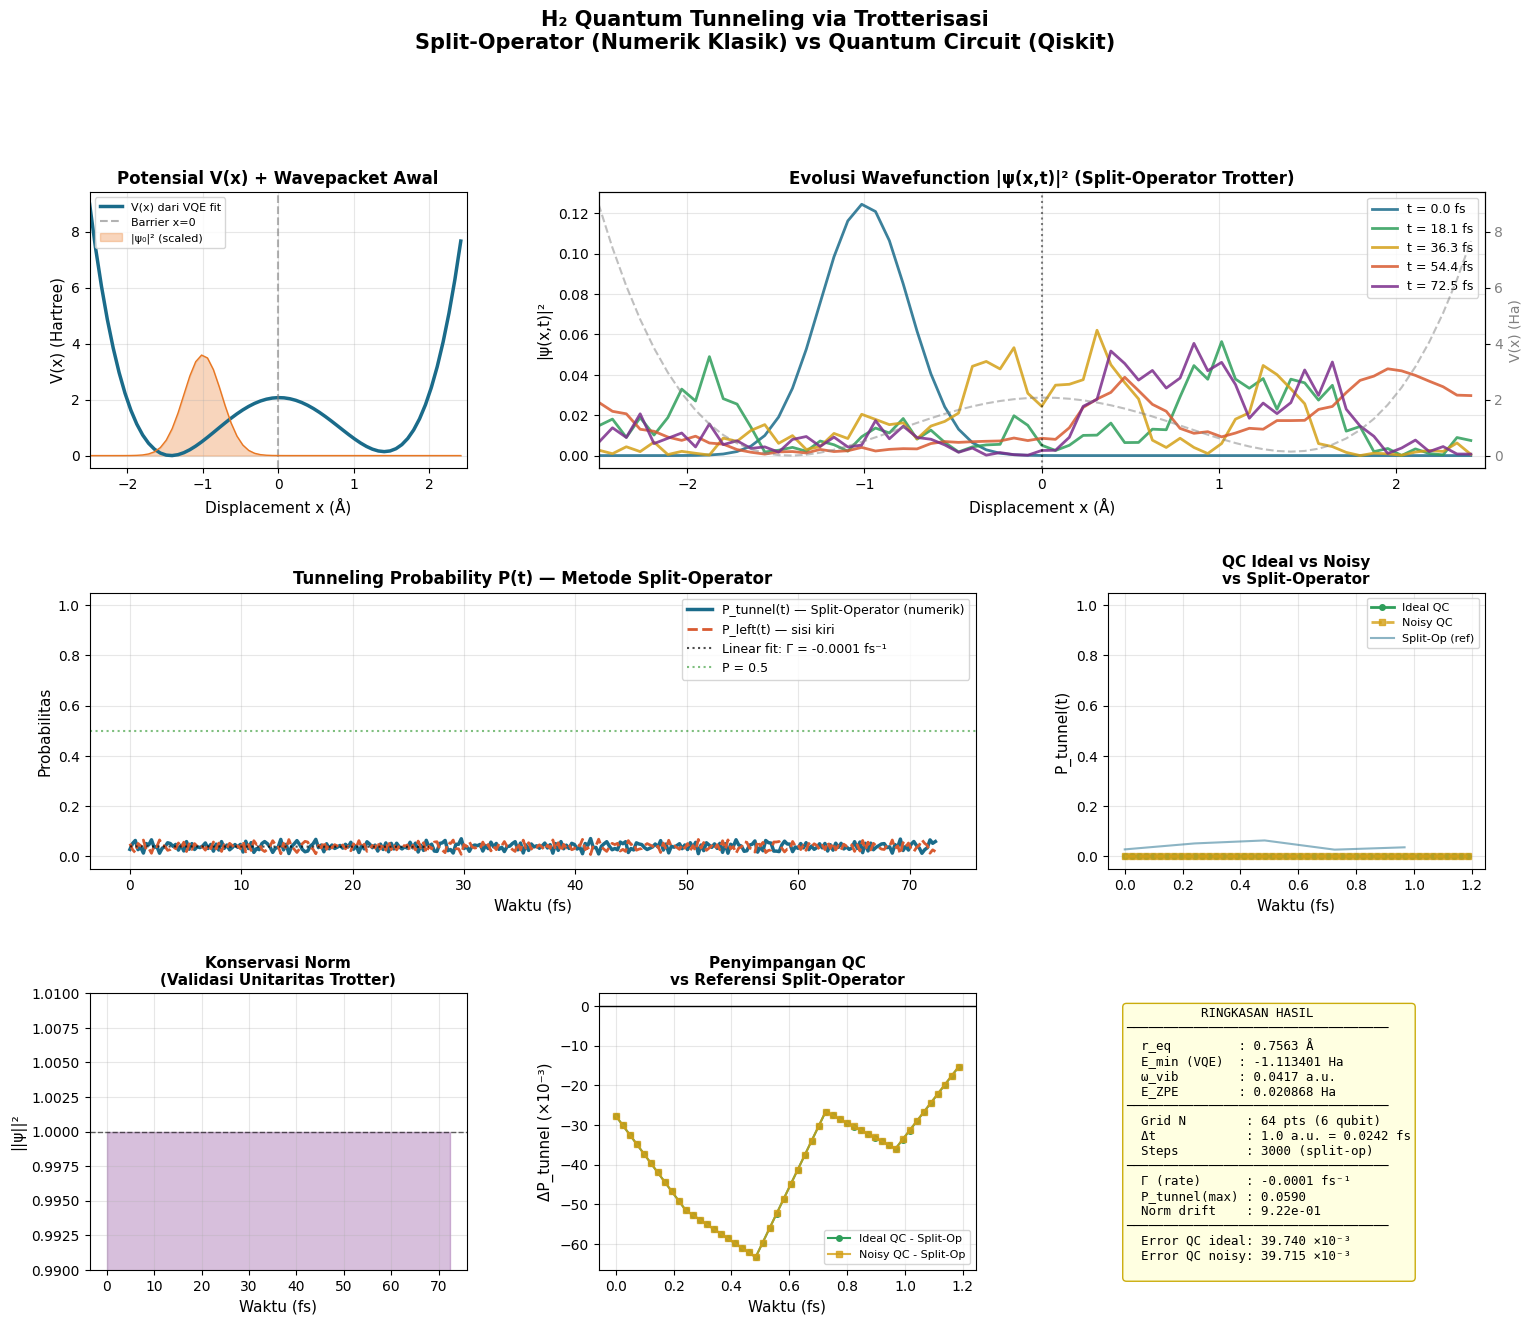

In [ ]:
from matplotlib import gridspec

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── Plot 1: Kurva Potensial V(x) ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, V_diag, color="#1A6B8A", lw=2.5, label="V(x) dari VQE fit")
ax1.axvline(x_barrier, color='gray', ls='--', alpha=0.6, label='Barrier x=0')
 
# Plot wavepacket awal
psi0_prob = (np.abs(psi0)**2) / (np.abs(psi0)**2).max() * V_diag.max() * 0.4
ax1.fill_between(x, psi0_prob, alpha=0.3, color="#E87722", label='|ψ₀|² (scaled)')
ax1.plot(x, psi0_prob, color="#E87722", lw=1)
 
ax1.set_xlabel("Displacement x (Å)", fontsize=11)
ax1.set_ylabel("V(x) (Hartree)", fontsize=11)
ax1.set_title("Potensial V(x) + Wavepacket Awal", fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_xlim(-L, L)

# ── Plot 2: Snapshot wavefunction pada beberapa waktu ────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
 
# Jalankan ulang cepat untuk ambil snapshot
psi_snap = psi0.copy()
snapshots  = {0: np.abs(psi0)**2}
snap_times = [0, n_steps//4, n_steps//2, 3*n_steps//4, n_steps-1]
snap_colors = ["#1A6B8A", "#2E9E5A", "#D4A017", "#D85A30", "#7B2D8B"]
 
psi_tmp = psi0.copy()
snap_idx = 1
for step in range(n_steps):
    psi_tmp = trotter_step_splitop(psi_tmp, V_diag, T_diag, dt_au)
    if step + 1 in snap_times[1:]:
        snapshots[step + 1] = np.abs(psi_tmp)**2

ax2_r = ax2.twinx()
ax2_r.plot(x, V_diag, color='gray', lw=1.5, ls='--', alpha=0.5, label='V(x)')
ax2_r.set_ylabel("V(x) (Ha)", fontsize=10, color='gray')
ax2_r.tick_params(axis='y', labelcolor='gray')
 
for i, (step_n, prob_density) in enumerate(snapshots.items()):
    t_label = f"t = {step_n * dt_au * au2fs:.1f} fs"
    ax2.plot(x, prob_density, color=snap_colors[i], lw=2,
             label=t_label, alpha=0.85)
 
ax2.axvline(x_barrier, color='black', ls=':', alpha=0.5)
ax2.set_xlabel("Displacement x (Å)", fontsize=11)
ax2.set_ylabel("|ψ(x,t)|²", fontsize=11)
ax2.set_title("Evolusi Wavefunction |ψ(x,t)|² (Split-Operator Trotter)", 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(alpha=0.3)
ax2.set_xlim(-L, L)

# ── Plot 3: Tunneling Probability P(t) — Split-Operator ──────────────────────
ax3 = fig.add_subplot(gs[1, :2])
 
ax3.plot(time_fs_so, prob_right_so, color="#1A6B8A", lw=2.5,
         label="P_tunnel(t) — Split-Operator (numerik)")
ax3.plot(time_fs_so, prob_left_so, color="#D85A30", lw=2, ls='--',
         label="P_left(t) — sisi kiri")
 
# Tampilkan fit linear (tunneling rate)
t_line     = np.linspace(0, time_fs_so[n_fit-1] * 1.5, 100)
P_fit_line = coeffs_rate[0] * t_line + coeffs_rate[1]
ax3.plot(t_line, np.clip(P_fit_line, 0, 1), 'k:', lw=1.5, alpha=0.7,
         label=f"Linear fit: Γ = {gamma_rate:.4f} fs⁻¹")
 
ax3.axhline(0.5, color='green', ls=':', alpha=0.5, label='P = 0.5')
ax3.set_xlabel("Waktu (fs)", fontsize=11)
ax3.set_ylabel("Probabilitas", fontsize=11)
ax3.set_title("Tunneling Probability P(t) — Metode Split-Operator", 
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
ax3.set_ylim(-0.05, 1.05)

# ── Plot 4: Perbandingan Ideal vs Noisy (Quantum Circuit) ────────────────────
ax4 = fig.add_subplot(gs[1, 2])
 
ax4.plot(time_fs_qc, prob_right_ideal, 'o-', color="#2E9E5A", lw=2, 
         ms=4, label="Ideal QC")
ax4.plot(time_fs_qc, prob_right_noisy, 's--', color="#D4A017", lw=2, 
         ms=4, alpha=0.8, label="Noisy QC")
# Overlay split-operator untuk perbandingan
mask_qc = time_fs_so <= time_fs_qc[-1]
ax4.plot(time_fs_so[mask_qc], prob_right_so[mask_qc], color="#1A6B8A", 
         lw=1.5, alpha=0.5, label="Split-Op (ref)")
 
ax4.set_xlabel("Waktu (fs)", fontsize=11)
ax4.set_ylabel("P_tunnel(t)", fontsize=11)
ax4.set_title("QC Ideal vs Noisy\nvs Split-Operator", 
              fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)
ax4.set_ylim(-0.05, 1.05)

# ── Plot 5: Norm conservation (validasi Trotter) ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
 
ax5.plot(time_fs_so, norm_check_so, color="#7B2D8B", lw=2)
ax5.axhline(1.0, color='black', ls='--', lw=1, alpha=0.6)
ax5.fill_between(time_fs_so, norm_check_so, 1.0, alpha=0.3, color="#7B2D8B")
ax5.set_xlabel("Waktu (fs)", fontsize=11)
ax5.set_ylabel("||ψ||²", fontsize=11)
ax5.set_title("Konservasi Norm\n(Validasi Unitaritas Trotter)", 
              fontsize=11, fontweight='bold')
ax5.grid(alpha=0.3)
ax5.set_ylim(0.99, 1.01)

# ── Plot 6: Error (Ideal QC - Split-Op) ──────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
 
# Interpolasi split-op ke time grid QC
from scipy.interpolate import interp1d
interp_so = interp1d(time_fs_so, prob_right_so, kind='linear', 
                      fill_value='extrapolate')
P_so_interp = interp_so(time_fs_qc)
 
err_ideal = (prob_right_ideal - P_so_interp) * 1000
err_noisy = (prob_right_noisy - P_so_interp) * 1000
 
ax6.plot(time_fs_qc, err_ideal, 'o-', color="#2E9E5A", ms=4, 
         label="Ideal QC - Split-Op")
ax6.plot(time_fs_qc, err_noisy, 's-', color="#D4A017", ms=4, 
         alpha=0.8, label="Noisy QC - Split-Op")
ax6.axhline(0, color='black', lw=1)
ax6.set_xlabel("Waktu (fs)", fontsize=11)
ax6.set_ylabel("ΔP_tunnel (×10⁻³)", fontsize=11)
ax6.set_title("Penyimpangan QC\nvs Referensi Split-Operator", 
              fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

# ── Plot 7: Ringkasan hasil ───────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
 
summary = (
    f"{'RINGKASAN HASIL':^35}\n"
    f"{'─'*35}\n"
    f"  r_eq         : {r_eq:.4f} Å\n"
    f"  E_min (VQE)  : {E_min:.6f} Ha\n"
    f"  ω_vib        : {np.sqrt(2*c2n*alpha/mu_au):.4f} a.u.\n"
    f"  E_ZPE        : {0.5*np.sqrt(2*c2n*alpha/mu_au):.6f} Ha\n"
    f"{'─'*35}\n"
    f"  Grid N        : {N} pts ({n_qubits} qubit)\n"
    f"  Δt            : {dt_au} a.u. = {dt_au*au2fs:.4f} fs\n"
    f"  Steps         : {n_steps} (split-op)\n"
    f"{'─'*35}\n"
    f"  Γ (rate)      : {gamma_rate:.4f} fs⁻¹\n"
    f"  P_tunnel(max) : {prob_right_so[-1]:.4f}\n"
    f"  Norm drift    : {abs(norm_check_so[-1]-1.0):.2e}\n"
    f"{'─'*35}\n"
    f"  Error QC ideal: {np.abs(err_ideal).mean():.3f} ×10⁻³\n"
    f"  Error QC noisy: {np.abs(err_noisy).mean():.3f} ×10⁻³\n"
)
 
ax7.text(0.05, 0.95, summary, transform=ax7.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', 
                   edgecolor='#C8A800', alpha=0.95))

fig.suptitle(
    "H₂ Quantum Tunneling via Trotterisasi\n"
    "Split-Operator (Numerik Klasik) vs Quantum Circuit (Qiskit)",
    fontsize=15, fontweight='bold', y=1.01
)
 
#plt.savefig("/mnt/user-data/outputs/h2_tunneling_trotter.png", 
#           dpi=150, bbox_inches='tight')
plt.show()